In [1]:

import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns
import json
!pip install pycaret
from pycaret.regression import *

     |████████████████████████████████| 301 kB 291 kB/s            
     |████████████████████████████████| 24.2 MB 1.7 MB/s            
     |████████████████████████████████| 25.9 MB 823 kB/s             
     |████████████████████████████████| 167 kB 79.0 MB/s            
     |████████████████████████████████| 114 kB 45.5 MB/s            
  Preparing metadata (setup.py) ... - done
     |████████████████████████████████| 15.6 MB 42.0 MB/s            
     |████████████████████████████████| 10.4 MB 37.8 MB/s            
     |████████████████████████████████| 636 kB 68.5 MB/s            
     |████████████████████████████████| 184 kB 46.6 MB/s            
     |████████████████████████████████| 1.0 MB 71.3 MB/s            
     |████████████████████████████████| 14.8 MB 57.5 MB/s            
     |████████████████████████████████| 58 kB 4.4 MB/s             
  Preparing metadata (setup.py) ... - done
     |████████████████████████████████| 79 kB 7.3 MB/s             
  Created wh




<div style=' background-image: url("https://www.youtube.com/img/desktop/yt_1200.png");
  width: 100%;
  height: 250px;
  background-position: center;
  background-size: cover;
          '> </div>

<h1 style='background:#b4edcf; border:0; color:black; width: 100%;  text-align: center; height:50px; padding: 20px 0;'>
   <center>  Tricking Youtube | Dislikes Prediction  </center> </h1> 

    
   

# Introduction

At the end of the last year, Youtube announced that the "dislike" option would be removed to ensure respectul interactions between viewers and creators, avoiding harassaments in form of "dislike attacks". 

This decision was not accepted by the Youtube community as they believe that this move was done to avoid negative and honest feedbacks that could affects the companies badly: this theory is backed by the facts that:
* Among the 20 most-disliked videos of all time, 16 of them belong to companies.
* The most disliked video is "YouTube Rewind 2018: Everyone Controls Rewind" published by Youtube itself.

Whatever the real truth is, the Youtube users miss this useful option because it helped them to understand if a video contains good content or not, avoing them to waste time or fall into scams (for example, dislikes are very useful to understand if a tutorial video really helps).

In this notebook we will use the datasets "Youtube Dislikes Dataset" and "Youtube Trending Video Dataset" to attempt the prediction of dislikes.

# Data reading

The first data we are going to read is the trending dataset.

In [2]:
#we need these features to join the datasets (video_id) and to add futher data (rest of them)
col=["video_id","categoryId","comments_disabled","ratings_disabled"]
# we only need these countries because the dislikes dataset has only data about these countries.
countries=["GB","US","CA"]
trending_ds=pd.DataFrame(columns=col)
for country in countries:
    trending_ds=trending_ds.append(pd.read_csv("/kaggle/input/youtube-trending-video-dataset/"+country+"_youtube_trending_data.csv")[col])

In [3]:
trending_ds.head(3)

,video_id,categoryId,comments_disabled,ratings_disabled
0,J78aPJ3VyNs,24,False,False
1,9nidKH8cM38,27,False,False
2,M9Pmf9AB4Mo,20,False,False


Now we will read the dislike dataset.

In [4]:
dislike_ds=pd.read_csv("/kaggle/input/youtube-dislikes-dataset/youtube_dislike_dataset.csv")
dislike_ds.head(3)

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments
0,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi..."
1,--14w5SOEUs,Migos - Avalanche (Official Video),UCGIelM2Dj3zza3xyV3pL3WQ,MigosVEVO,2021-06-10 16:00:00,15352638,359277,7479,18729,Migos Avalanche Quality Control Music/Motown R...,"Watch the the official video for Migos - ""Aval...",Migos just makes me want to live my live to th...
2,--40TEbZ9Is,Supporting Actress in a Comedy: 73rd Emmys,UClBKH8yZRcM4AsRjDVEdjMg,Television Academy,2021-09-20 01:03:32,925281,11212,401,831,,Hannah Waddingham wins the Emmy for Supporting...,Hannah's energy bursts through any screen. Wel...


# EDA

## Basic data manipulation

Are there any duplicated rows?

In [5]:
print("Trending dataset duplicated: ",trending_ds.duplicated().sum())
print("Dislikes dataset duplicated: ",dislike_ds.duplicated().sum())

Trending dataset duplicated:  293384
Dislikes dataset duplicated:  0


What about NaN values?

In [6]:
print("Trending dataset duplicated: ",trending_ds.isna().sum().sum())
print("Dislikes dataset duplicated: ",dislike_ds.isna().sum())

Trending dataset duplicated:  0
Dislikes dataset duplicated:  video_id           0
title              0
channel_id         0
channel_title      0
published_at       0
view_count         0
likes              0
dislikes           0
comment_count      0
tags               0
description        0
comments         158
dtype: int64


We can ignore the NaNs comments as we will ignore this feature.

Let's merge the datasets!

In [7]:
data=pd.merge(dislike_ds,trending_ds, left_on="video_id",right_on="video_id")
data.head(3)

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments,categoryId,comments_disabled,ratings_disabled
0,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi...",17,False,False
1,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi...",17,False,False
2,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi...",17,False,False


We want to keep only the useful features for the regression.

In [8]:
data=data[["video_id","title","channel_title","view_count","likes","dislikes","comment_count","categoryId","comments_disabled","ratings_disabled"]]
data.head(3)

,video_id,title,channel_title,view_count,likes,dislikes,comment_count,categoryId,comments_disabled,ratings_disabled
0,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,Bundesliga,1048888,19515,226,1319,17,False,False
1,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,Bundesliga,1048888,19515,226,1319,17,False,False
2,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,Bundesliga,1048888,19515,226,1319,17,False,False


What kind of features we have in our dataset?

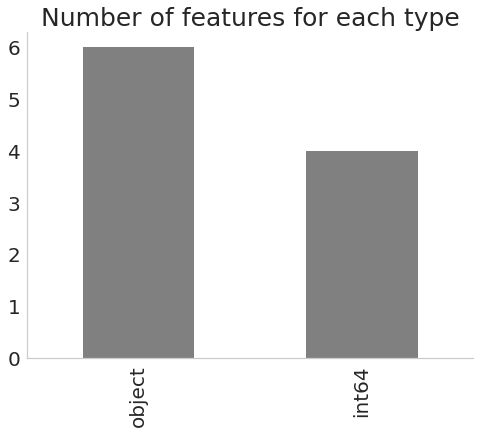

In [9]:
plt.figure(figsize = (8,6))
ax = data.dtypes.value_counts().plot(kind='bar',grid = False,fontsize=20,color='grey')
plt.title("Number of features for each type",fontsize=25)
sns.despine()

In [10]:
int_features=[x for x in data.columns[3:] if(data[x].dtype in ["int64"] and x!="dislikes")]
ob_features=[x for x in data.columns[3:] if(data[x].dtype in ["O"])]

## Numeric features

Let's plot the histogram of the target feature (Dislikes) before and after the log transformation.

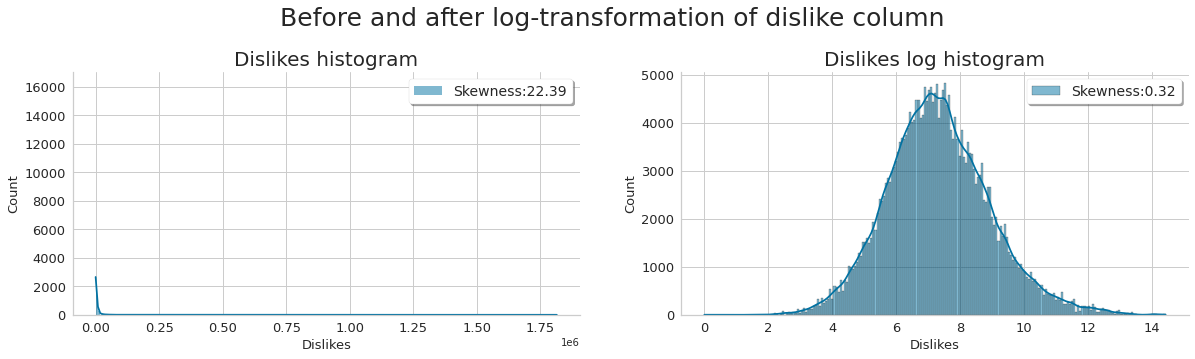

In [11]:
plt.figure(figsize = (20,5))
plt.subplots_adjust(top=0.8)
plt.suptitle("Before and after log-transformation of dislike column",fontsize=25)
ax = plt.subplot(1,2,1)
sns.histplot(data["dislikes"],palette='Blues_r',kde=True,label="Skewness:"+str(round(data["dislikes"].skew(),2)))
plt.legend(fontsize=14,shadow=True,fancybox=True, frameon=True)
ax.set_title("Dislikes"+' histogram',fontsize=20)
plt.tick_params(labelsize=13)
plt.xlabel("Dislikes",fontsize=13)
plt.ylabel("Count",fontsize=13)


ax = plt.subplot(1,2,2)
sns.histplot(np.log1p(data["dislikes"]),palette='Blues_r',kde=True,label="Skewness:"+str(round(np.log1p(data["dislikes"]).skew(),2)))
plt.legend(fontsize=14,shadow=True,fancybox=True, frameon=True)
ax.set_title("Dislikes"+' log histogram',fontsize=20)
plt.tick_params(labelsize=13)
plt.xlabel("Dislikes",fontsize=13)
plt.ylabel("Count",fontsize=13)
sns.despine()
plt.show()

As we can see in the first plot, the dislikes are distribuited in a very wide range, resulting in an high skewness of **22.62**.
In the second plot it's clear that the log transformation heavily helped, bringing down the skewness to **0.39**.

This feature will be log-transformed.

In [12]:
data["dislikes"]=np.log1p(data["dislikes"])

Let's repeat the same analysis on the other numeric features.

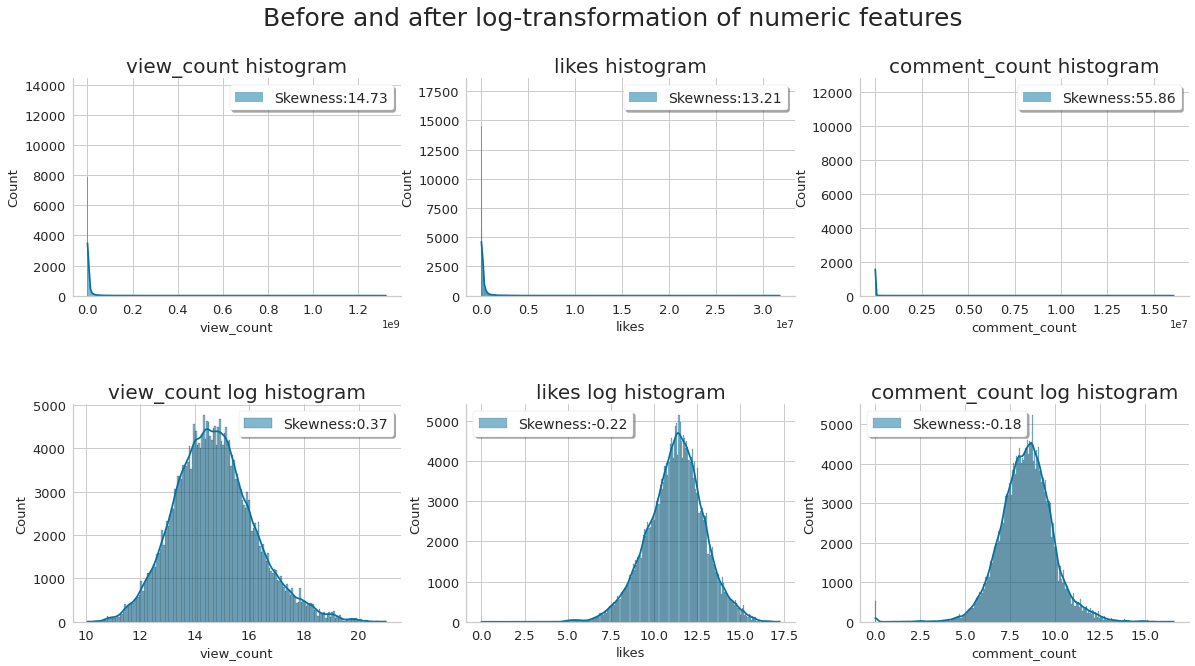

In [13]:
plt.figure(figsize = (20,10))
plt.subplots_adjust(hspace=0.5)
plt.suptitle("Before and after log-transformation of numeric features",fontsize=25)
for i,x in enumerate(int_features):
    ax = plt.subplot(2,3,i+1)
    sns.histplot(data[x],palette='Blues_r',kde=True,label="Skewness:"+str(round(data[x].skew(),2)))
    plt.legend(fontsize=14,shadow=True,fancybox=True, frameon=True)
    ax.set_title(x+' histogram',fontsize=20)
    plt.tick_params(labelsize=13)
    plt.xlabel(x,fontsize=13)
    plt.ylabel("Count",fontsize=13)


for i,x in enumerate(int_features):
    ax = plt.subplot(2,3,i+4)
    sns.histplot(np.log1p(data[x]),palette='Blues_r',kde=True,label="Skewness:"+str(round(np.log1p(data[x]).skew(),2)))
    plt.legend(fontsize=14,shadow=True,fancybox=True, frameon=True)
    ax.set_title(x+' log histogram',fontsize=20)
    plt.tick_params(labelsize=13)
    plt.xlabel(x,fontsize=13)
    plt.ylabel("Count",fontsize=13)
sns.despine()
plt.show()

We can observe the same pattern here, so we will log-transform these features too.

In [14]:
for x in int_features:
    data[x]=np.log1p(data[x])

To find any anomaly in the data we can produce regplots.

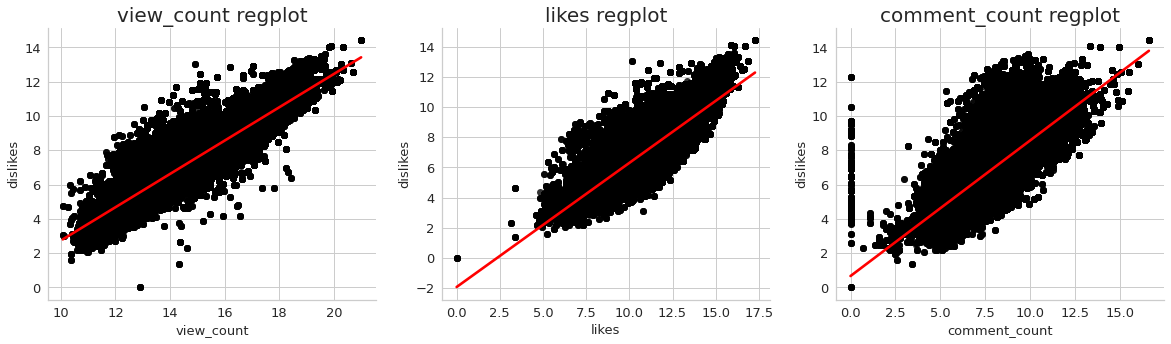

In [15]:
plt.figure(figsize = (20,5))
for i,x in enumerate(int_features):
    ax = plt.subplot(1,3,i+1)
    sns.regplot(data=data,x=x,y="dislikes",scatter_kws={"color": "black"}, line_kws={"color": "red"})
    ax.set_title(x+' regplot',fontsize=20)
    plt.tick_params(labelsize=13)
    plt.xlabel(x,fontsize=13)
    plt.ylabel("dislikes",fontsize=13)
sns.despine()
plt.show()

In the likes and comment_count scatterplots we can notice some 0 values that can be removed.

We can also thee that these features are higly correlated with dislikes.

In [16]:
data=data[data["likes"]>0]
data=data[data["comment_count"]>0]

# Categorical features

In [17]:
#these conversions will be only useful for futher steps but these features will remain categorical.
data["comments_disabled"]=pd.to_numeric(data["comments_disabled"])
data["ratings_disabled"]=pd.to_numeric(data["ratings_disabled"])
data["categoryId"]=pd.to_numeric(data["categoryId"])

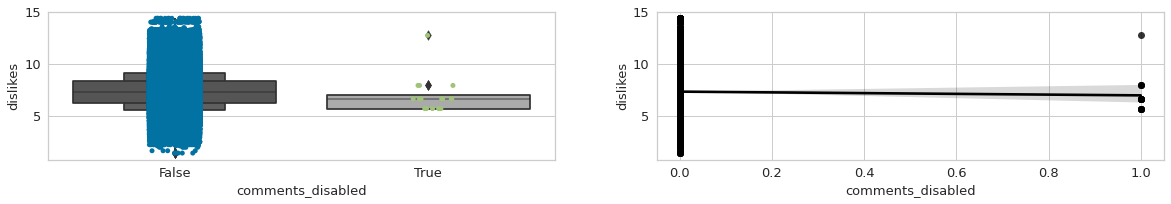

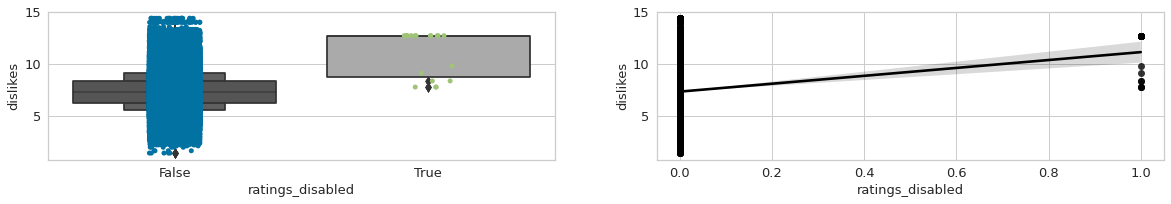

In [18]:
for i,feat in enumerate(["comments_disabled","ratings_disabled"]):
    plt.figure(figsize=(20,6))
    #plt.subplots_adjust(wspace=0.3)
    plt.subplot(2,2,i+1+i%2)
    sns.boxenplot(data=data, x=feat,y='dislikes',palette='gray')
    sns.stripplot(data=data, x=feat,y='dislikes')
    plt.tick_params(labelsize=13)
    plt.xlabel(feat,fontsize=13)
    plt.ylabel("dislikes",fontsize=13)
    plt.subplot(2,2,i*1+2+i%2)
    sns.regplot(data=data, x=feat,y='dislikes',color='black')
    plt.tick_params(labelsize=13)
    plt.xlabel(feat,fontsize=13)
    plt.ylabel("dislikes",fontsize=13)
plt.show()

We don't have a lot of entries where the ratings and the comments are disabled but we can see how comments and rating are linked to higher dislike values when they are disabled.

## Correlations

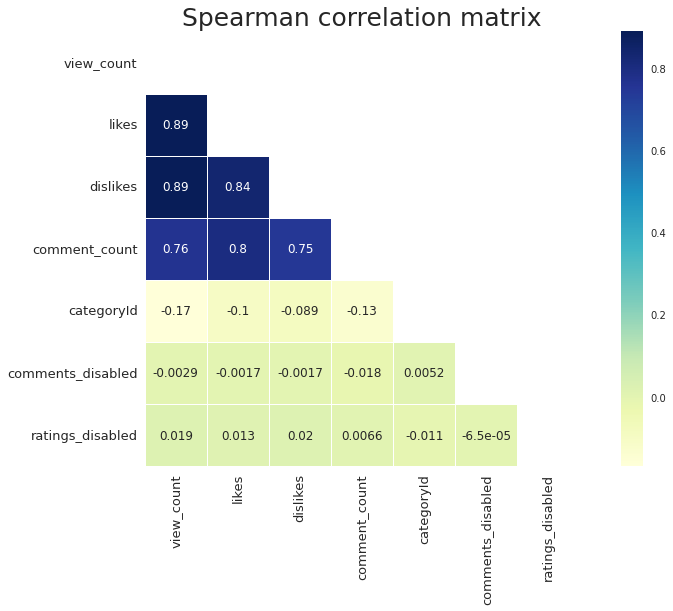

In [19]:
corr=data.corr()
plt.figure(figsize=(15,8))
plt.title("Spearman correlation matrix", fontsize=25)
ax=sns.heatmap(corr,annot=True,square=True, linewidths=.5,cmap="YlGnBu",mask=np.triu(np.ones_like(corr)))
plt.tick_params(labelsize=13)

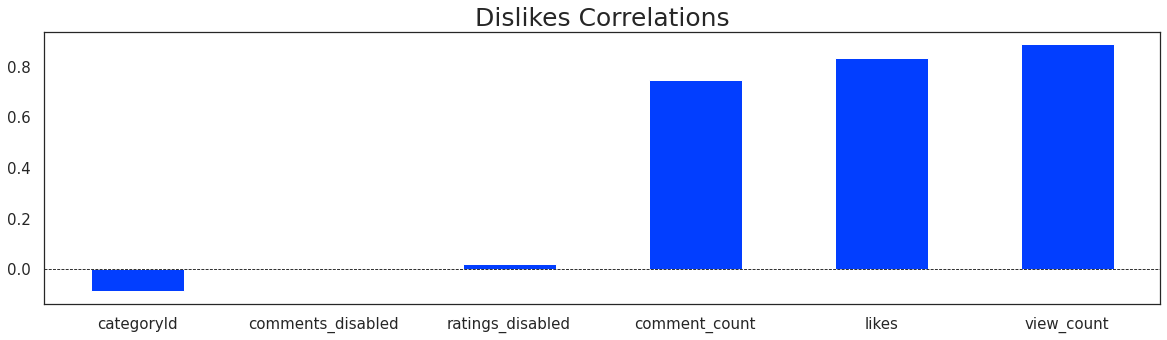

In [20]:
sns.set(font_scale=1)
plt.figure(figsize=(20, 5))
sns.set_style("white")
sns.set_palette("bright")
ax=corr['dislikes'].sort_values()[:-1].plot.bar(rot=0)
plt.gca().set_facecolor('#FFFFFF')
plt.title('Dislikes Correlations',fontsize=25)
plt.axhline(y=0, color="black", linestyle="--",linewidth=0.8)
plt.tick_params(labelsize=15)

The dislikes are highly correlated to comment_count, likes and view_count.

# Models definition, training and evaluation
We will use the pycaret library to define some models and then feed them to a soft-coding classifier. 

In [21]:
#The features that will be used by the models to predict the dislikes.
cols_model=["view_count","likes","comment_count","ratings_disabled","comments_disabled","categoryId"]
reg = setup(data = data[cols_model+["dislikes"]],
           target = 'dislikes',
           normalize = True,
           preprocess = True,
           verbose = False,
           silent = True,
           categorical_features=["ratings_disabled","comments_disabled","categoryId"],
           numeric_features=["view_count","likes","comment_count"],
           remove_outliers=True)

Let's define and train the models.

## Training and evaluation

In [22]:
#The create_model function creates, trains and evaluates the performance of a given estimator using cross validation (k=10 by default). 
catboost = create_model('catboost')
lightgbm = create_model('lightgbm')
et=create_model("et")

,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0.0055,0.0048,0.0695,0.9981,0.0100,0.0010
1,0.0044,0.0034,0.0587,0.9987,0.0086,0.0008
2,0.0057,0.0051,0.0718,0.9980,0.0107,0.0010
3,0.0053,0.0055,0.0745,0.9978,0.0111,0.0009
4,0.0055,0.0040,0.0632,0.9984,0.0092,0.0009
5,0.0051,0.0042,0.0645,0.9984,0.0097,0.0009
6,0.0055,0.0051,0.0714,0.9980,0.0098,0.0009
7,0.0057,0.0055,0.0743,0.9979,0.0100,0.0009
8,0.0051,0.0038,0.0620,0.9985,0.0092,0.0009
9,0.0054,0.0042,0.0645,0.9984,0.0093,0.0009


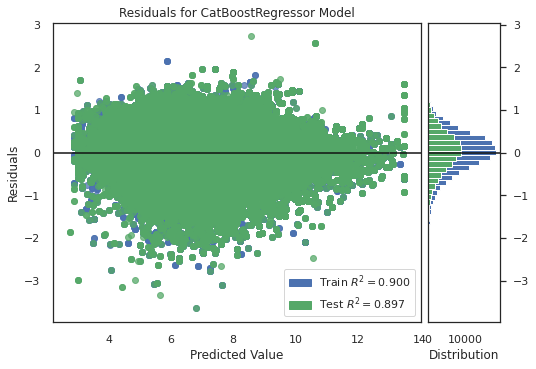

In [23]:
plot_model(catboost, plot='residuals')

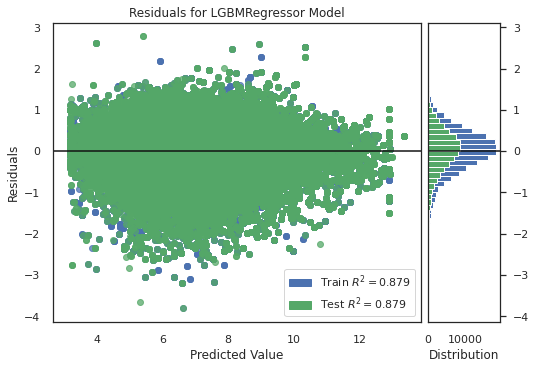

In [24]:
plot_model(lightgbm, plot='residuals')

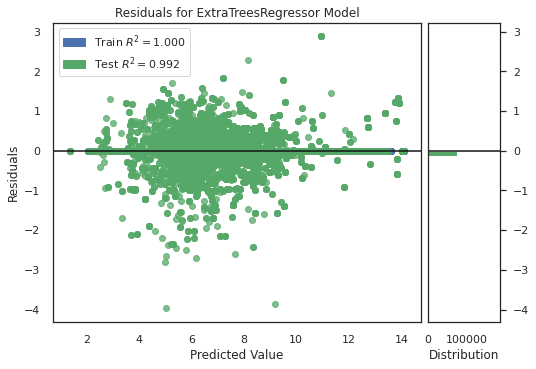

In [25]:
plot_model(et, plot='residuals')

Now we want to know the feature importance for each model: this can be made with the followings plots.

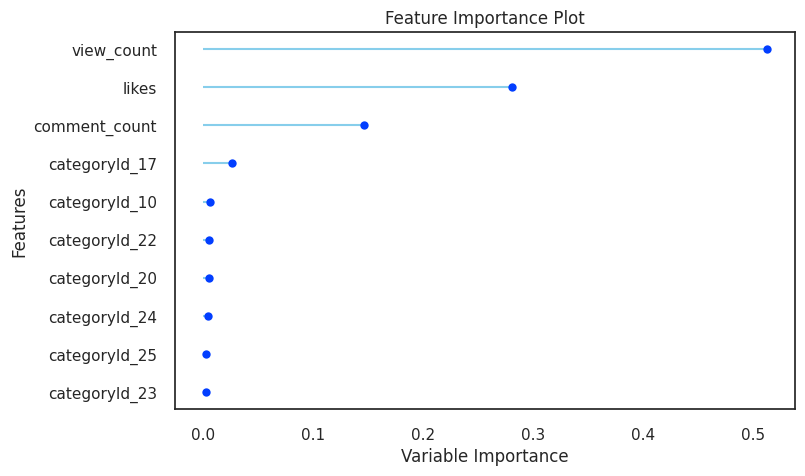

In [26]:
plot_model(et, plot="feature")

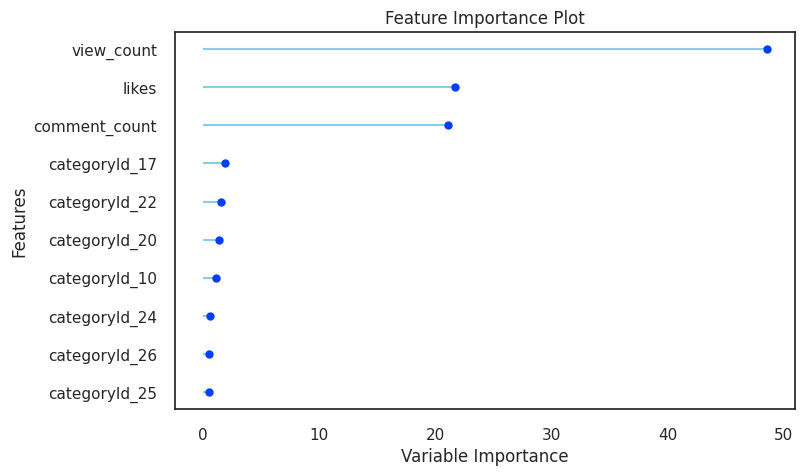

In [27]:
plot_model(catboost, plot="feature")

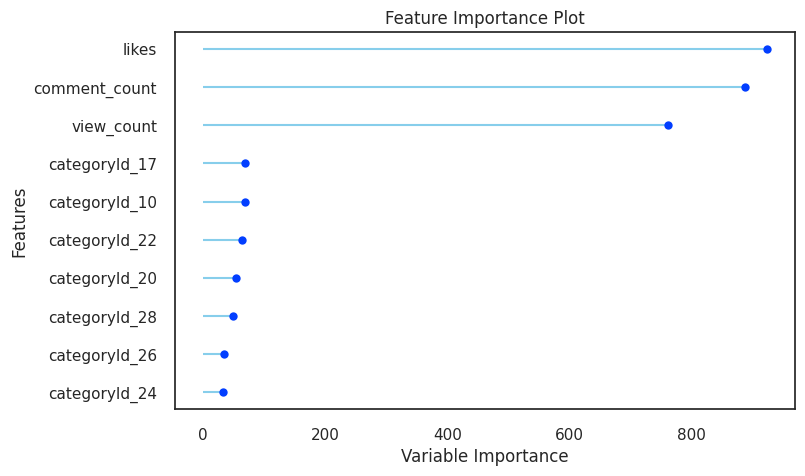

In [28]:
plot_model(lightgbm, plot="feature")

There are sligh differences between these plot but they can help to build a stronger classifier: this is what we are going to go!

## Ensembled model

In [29]:
blend = blend_models(estimator_list = [catboost,lightgbm,et])

,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,0.2732,0.1295,0.3599,0.9500,0.0454,0.0394
1,0.2755,0.1321,0.3635,0.9494,0.0458,0.0396
2,0.2760,0.1331,0.3648,0.9487,0.0463,0.0399
3,0.2735,0.1292,0.3594,0.9494,0.0456,0.0394
4,0.2735,0.1289,0.3591,0.9494,0.0455,0.0395
5,0.2718,0.1285,0.3584,0.9501,0.0454,0.0392
6,0.2734,0.1301,0.3607,0.9489,0.0456,0.0394
7,0.2754,0.1318,0.3631,0.9488,0.0457,0.0397
8,0.2736,0.1292,0.3594,0.9499,0.0454,0.0395
9,0.2710,0.1275,0.3571,0.9496,0.0450,0.0391


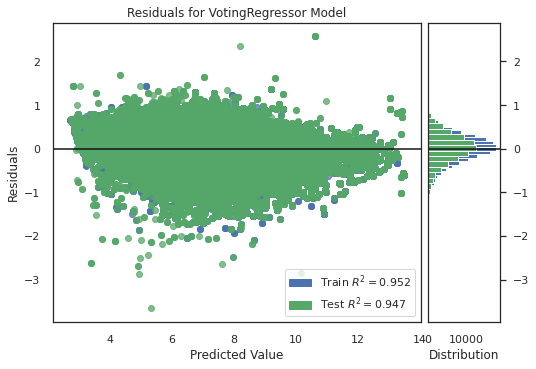

In [30]:
plot_model(blend, plot='residuals')

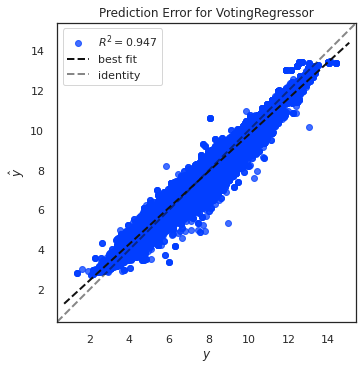

In [31]:
plot_model(blend, plot='error')

The ensembled model obtained an R-squarred of **0.95** on the training set and an R-squarred of **0.87** on the testing set, that is the model explains the 87% of the variance, which is not bad considering that we trained the models only on 7 features!

# End of the notebook

**Thank you for reading this notebook and please upvote if you appreciated the work!**

**Leave a comment if you have any question or if you want to advice me some of your works!**